In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_clean.csv')

df.head()
original_df = df.copy()

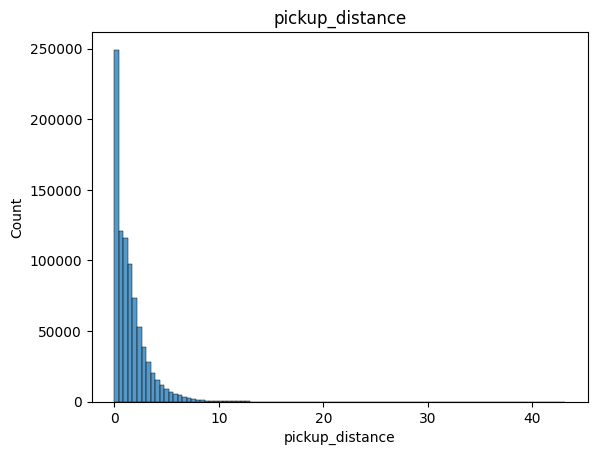

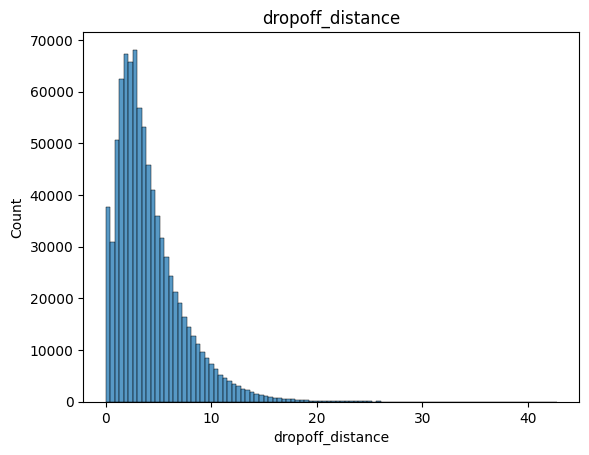

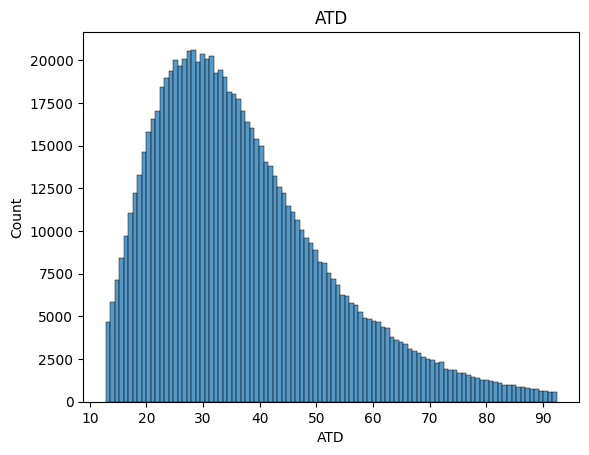

In [3]:
for col in ["pickup_distance", "dropoff_distance", "ATD"]:
    sns.histplot(df[col], bins=100)
    plt.title(col)
    plt.show()

<Axes: xlabel='dropoff_distance', ylabel='ATD'>

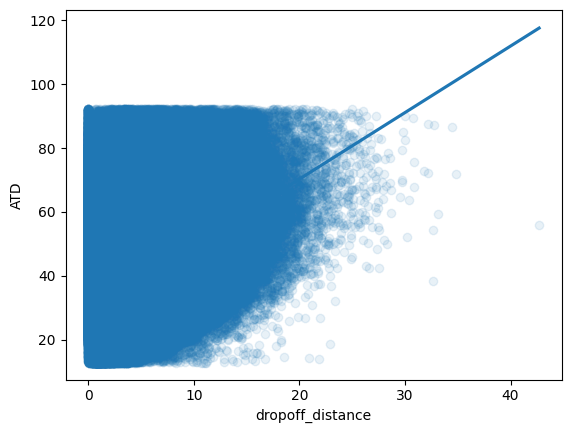

In [4]:
sns.regplot(
    data=df,
    x="dropoff_distance",
    y="ATD",
    scatter_kws={"alpha":0.1}
)

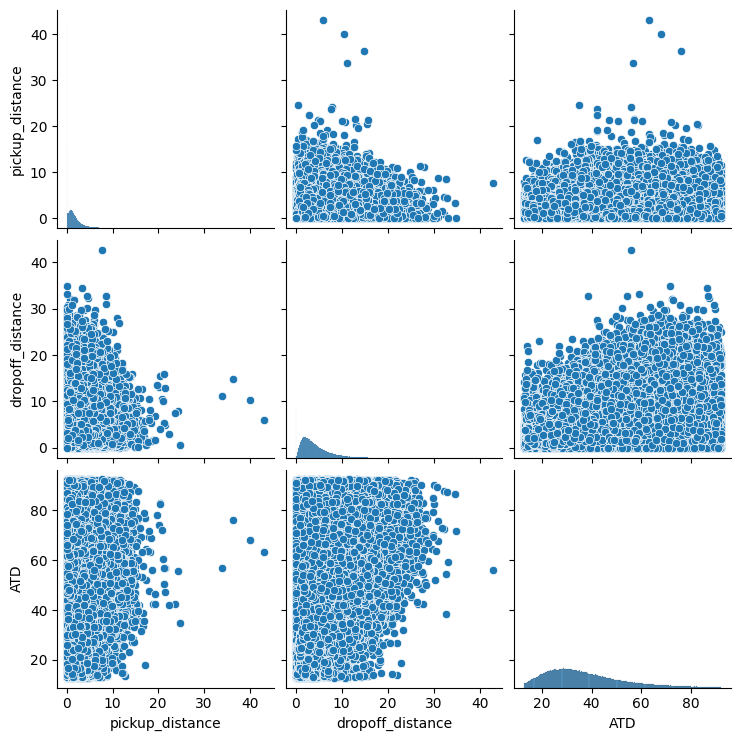

In [5]:
sns.pairplot(df[["pickup_distance", "dropoff_distance", "ATD"]])



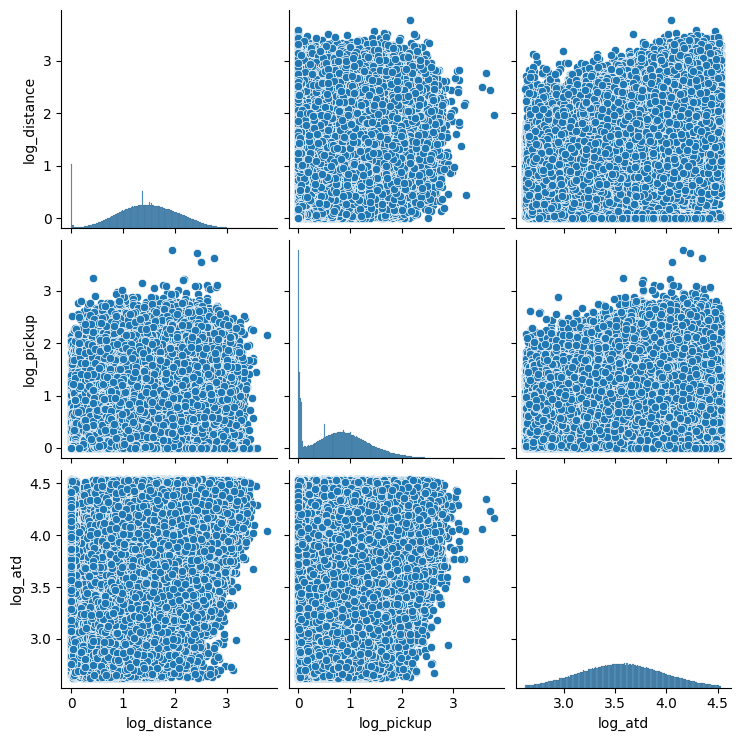

In [6]:
df["log_distance"] = np.log1p(df["dropoff_distance"])
df["log_pickup"] = np.log1p(df["pickup_distance"])
df["log_atd"] = np.log1p(df["ATD"])


sns.pairplot(df[["log_distance", "log_pickup", "log_atd"]])

/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_59911/2142088419.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_bin")["ATD"].mean().plot()


<Axes: xlabel='distance_bin'>

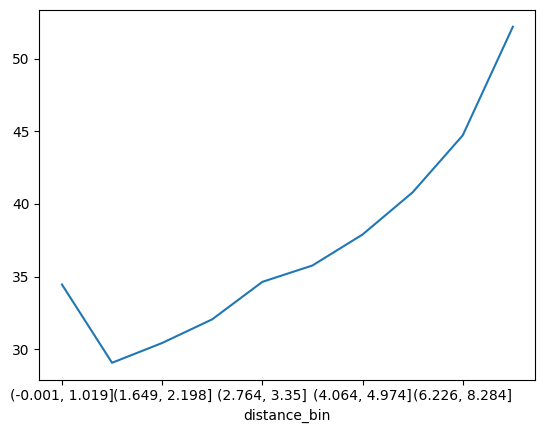

In [7]:
df["distance_bin"] = pd.qcut(df["dropoff_distance"], q=10)

df.groupby("distance_bin")["ATD"].mean().plot()

/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_59911/318890134.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pickup_bin")["ATD"].mean().plot()


<Axes: xlabel='pickup_bin'>

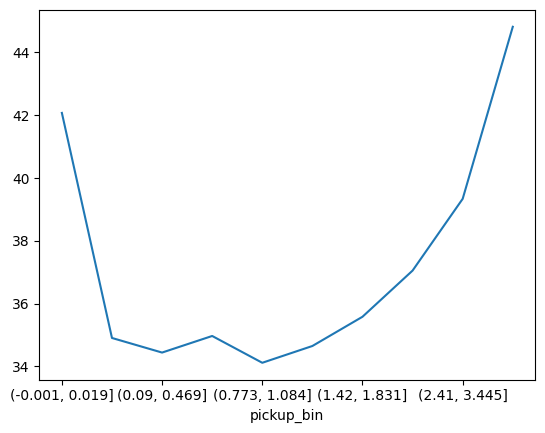

In [8]:
df["pickup_bin"] = pd.qcut(df["pickup_distance"], q=10)

df.groupby("pickup_bin")["ATD"].mean().plot()

/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_59911/1283493198.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_bin")["log_atd"].mean().plot()


<Axes: xlabel='distance_bin'>

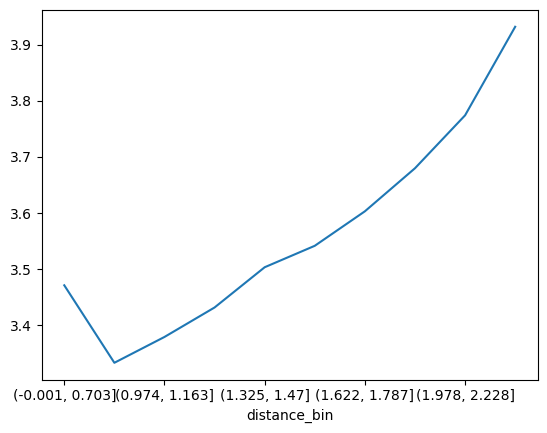

In [9]:
df["distance_bin"] = pd.qcut(df["log_distance"], q=10)

df.groupby("distance_bin")["log_atd"].mean().plot()

/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_59911/428438380.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pickup_bin")["log_atd"].mean().plot()


<Axes: xlabel='pickup_bin'>

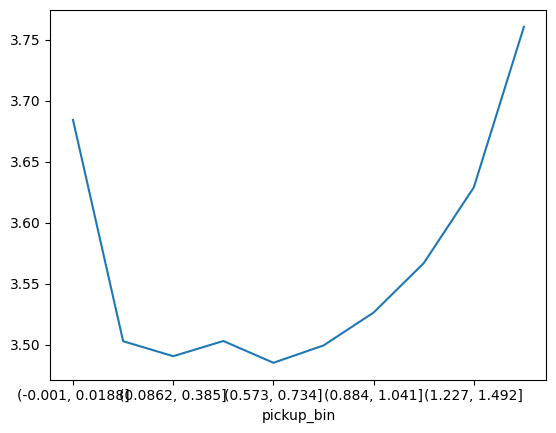

In [10]:
df["pickup_bin"] = pd.qcut(df["log_pickup"], q=10)

df.groupby("pickup_bin")["log_atd"].mean().plot()

# Timestamp treatment

In [11]:
df["eater_request_timestamp_local"] = pd.to_datetime(df['eater_request_timestamp_local'])
df["restaurant_offered_timestamp_local"] = pd.to_datetime(df['restaurant_offered_timestamp_local'])


df["hour"] = df["eater_request_timestamp_local"].dt.hour
df["day_of_week"] = df["eater_request_timestamp_local"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

In [12]:
df = pd.get_dummies(
    df,
    columns=["territory", "courier_flow", "geo_archetype", "merchant_surface"],
    drop_first=True
)

In [13]:
df.columns

Index(['order_final_state_timestamp_local', 'eater_request_timestamp_local',
       'pickup_distance', 'dropoff_distance', 'ATD',
       'restaurant_offered_timestamp_local', 'missing_distance',
       'offered_equals_request', 'log_distance', 'log_pickup', 'log_atd',
       'distance_bin', 'pickup_bin', 'hour', 'day_of_week', 'is_weekend',
       'hour_sin', 'hour_cos', 'territory_Long Tail - Region',
       'territory_North', 'territory_South East', 'territory_West',
       'courier_flow_Logistics', 'courier_flow_Motorbike',
       'courier_flow_Onboarder', 'courier_flow_SUV', 'courier_flow_UberEats',
       'courier_flow_UberX', 'courier_flow_Unespecified',
       'geo_archetype_Defend CP', 'geo_archetype_Drive momentum',
       'geo_archetype_Play offense', 'geo_archetype_Unlaunched',
       'geo_archetype_Unspecified', 'merchant_surface_POS',
       'merchant_surface_Tablet', 'merchant_surface_Unspecified',
       'merchant_surface_Web/Mobile'],
      dtype='object')

In [17]:
original_df["eater_request_timestamp_local"] = pd.to_datetime(original_df['eater_request_timestamp_local'])
original_df["restaurant_offered_timestamp_local"] = pd.to_datetime(original_df['restaurant_offered_timestamp_local'])


post_assign_data_set = original_df[["territory", "courier_flow", "geo_archetype", "merchant_surface", "missing_distance", "offered_equals_request",
                           "eater_request_timestamp_local", "restaurant_offered_timestamp_local", "dropoff_distance",
                           "pickup_distance",  "ATD"]].copy()

pre_assign_data_set = original_df[["territory", "courier_flow", "geo_archetype", "merchant_surface", "missing_distance", 
                          "eater_request_timestamp_local", "dropoff_distance",
                          "pickup_distance",  "ATD"]].copy()
                         

In [15]:
# En pre no necesito offered_equals_request ni restaurant_offered_timestamp_local

# En post necesito offered_equals_request y restaurant_offered_timestamp_local diferencia 

In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# -----------------------------
# 1. TARGET
# -----------------------------
target = "ATD"

# -----------------------------
# 2. FEATURE ENGINEERING BASE Primer modelo, solo para pre assign
# -----------------------------
df_model = post_assign_data_set.copy()

# temporal
df_model["hour"] = df_model["eater_request_timestamp_local"].dt.hour
df_model["day_of_week"] = df_model["eater_request_timestamp_local"].dt.dayofweek
df_model["is_weekend"] = df_model["day_of_week"].isin([5,6]).astype(int)

# cíclicas
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

# distancia
df_model["total_distance"] = df_model["pickup_distance"] + df_model["dropoff_distance"]

# -----------------------------
# 3. FEATURES
# -----------------------------
num_cols = [
    "pickup_distance",
    "dropoff_distance",
    "total_distance"
]

cat_cols = [
    "territory",
    "courier_flow",
    "geo_archetype",
    "merchant_surface"
]

cyclical_cols = ["hour_sin", "hour_cos"]

# -----------------------------
# 4. TRANSFORMERS
# -----------------------------
# log transform
log_transformer = FunctionTransformer(np.log1p)

numeric_pipeline = Pipeline([
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

categorical_pipeline = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
    ("cyc", "passthrough", cyclical_cols)
])

# -----------------------------
# 5. STRATIFICATION
# -----------------------------
# Crear variable combinada (categoría + hora)
df_model["hour_bin"] = (df_model["hour"] // 3)  # agrupar horas

df_model["strata"] = (
    df_model["territory"].astype(str) + "_" +
    df_model["courier_flow"].astype(str) + "_" +
    df_model["hour_bin"].astype(str)
)

# evitar strata raras (muy pocas observaciones)
strata_counts = df_model["strata"].value_counts()
valid_strata = strata_counts[strata_counts > 10].index

df_model = df_model[df_model["strata"].isin(valid_strata)]

# -----------------------------
# 6. SPLIT
# -----------------------------
X = df_model[num_cols + cat_cols + cyclical_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["strata"]
)

# -----------------------------
# 7. PIPELINE FINAL
# -----------------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

# -----------------------------
# 8. TRANSFORM DATA
# -----------------------------
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# -----------------------------
# 9. OUTPUT INFO
# -----------------------------
print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

Train shape: (689649, 29)
Test shape: (172413, 29)


In [26]:
import joblib

# Features
joblib.dump(X_train_transformed, "X_train_transformed_pre_assign.pkl")
joblib.dump(X_test_transformed, "X_test_transformed_pre_assign.pkl")

# Targets
joblib.dump(y_train, "y_train_pre_assign.pkl")
joblib.dump(y_test, "y_test_pre_assign.pkl")

# Pipeline (MUY importante)
joblib.dump(pipeline, "preprocessing_pipeline_pre_assign.pkl")

['preprocessing_pipeline_pre_assign.pkl']

In [27]:

# -----------------------------
# 1. TARGET
# -----------------------------
target = "ATD" 

# -----------------------------
# 2. FEATURE ENGINEERING BASE 2 modelo (ya se sabe a que hora se asigno)
# -----------------------------
df_model = post_assign_data_set.copy()

# temporal
df_model["hour"] = df_model["eater_request_timestamp_local"].dt.hour
df_model["day_of_week"] = df_model["eater_request_timestamp_local"].dt.dayofweek
df_model["is_weekend"] = df_model["day_of_week"].isin([5,6]).astype(int)

# cíclicas
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

# distancia
df_model["total_distance"] = df_model["pickup_distance"] + df_model["dropoff_distance"]

# NUEVO: dispatch delay
df_model["dispatch_delay"] = (
    df_model["restaurant_offered_timestamp_local"] - 
    df_model["eater_request_timestamp_local"]
).dt.total_seconds() / 60

# flag ya existente
df_model["offered_equals_request"] = df_model["offered_equals_request"].astype(int)

# -----------------------------
# 3. FEATURES
# -----------------------------
num_cols = [
    "pickup_distance",
    "dropoff_distance",
    "total_distance",
    "dispatch_delay"
]

cat_cols = [
    "territory",
    "courier_flow",
    "geo_archetype",
    "merchant_surface"
]

binary_cols = ["offered_equals_request"]

cyclical_cols = ["hour_sin", "hour_cos"]

# -----------------------------
# 4. TRANSFORMERS
# -----------------------------
log_transformer = FunctionTransformer(np.log1p)

numeric_pipeline = Pipeline([
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

categorical_pipeline = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
    ("bin", "passthrough", binary_cols),
    ("cyc", "passthrough", cyclical_cols)
])

# -----------------------------
# 5. STRATIFICATION
# -----------------------------
df_model["hour_bin"] = (df_model["hour"] // 3)

df_model["strata"] = (
    df_model["territory"].astype(str) + "_" +
    df_model["courier_flow"].astype(str) + "_" +
    df_model["hour_bin"].astype(str)
)

# evitar strata raras
strata_counts = df_model["strata"].value_counts()
valid_strata = strata_counts[strata_counts > 10].index

df_model = df_model[df_model["strata"].isin(valid_strata)]

# -----------------------------
# 6. SPLIT
# -----------------------------
X = df_model[num_cols + cat_cols + binary_cols + cyclical_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["strata"]
)

# -----------------------------
# 7. PIPELINE FINAL
# -----------------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor)
])

# -----------------------------
# 8. TRANSFORM DATA
# -----------------------------
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# -----------------------------
# 9. OUTPUT INFO
# -----------------------------
print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

/Users/luisfernandocaporalmontesdeoca/miniconda3/envs/uber/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


Train shape: (689649, 31)
Test shape: (172413, 31)


/Users/luisfernandocaporalmontesdeoca/miniconda3/envs/uber/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [28]:
# Features
joblib.dump(X_train_transformed, "X_train_transformed_post_assign.pkl")
joblib.dump(X_test_transformed, "X_test_transformed_post_assign.pkl")

# Targets
joblib.dump(y_train, "y_train_post_assign.pkl")
joblib.dump(y_test, "y_test_post_assign.pkl")

# Pipeline (MUY importante)
joblib.dump(pipeline, "preprocessing_pipeline_post_assign.pkl")

['preprocessing_pipeline_post_assign.pkl']